# 🎨 Feature Engineering Masterclass

## 🎯 Learning Objectives
- Extract features from text, dates, and numerical data
- Apply mathematical transformations
- Create interaction and polynomial features
- Understand when and why each technique works

---

> **"Feature engineering is the art and science of creating the right inputs for your model."**

---

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ All libraries imported successfully!")
print("🎨 Ready to engineer some amazing features!")

✅ All libraries imported successfully!
🎨 Ready to engineer some amazing features!


## 🔍 Part 1: Feature Extraction from Text

Text data is everywhere! Let's extract meaningful numerical features from text.

In [2]:
# Create sample text data (product reviews)
reviews = [
    "This product is AMAZING!!! Highly recommend it!",
    "Terrible quality. Very disappointed :(",
    "It's okay, nothing special.",
    "BEST PURCHASE EVER! Love it so much!!!",
    "Waste of money. Do not buy.",
    "Good value for the price.",
    "Exceeded my expectations! Very happy :)",
    "Poor customer service and low quality."
]

# True ratings (1-5)
ratings = [5, 1, 3, 5, 1, 4, 5, 2]

df_reviews = pd.DataFrame({'review': reviews, 'rating': ratings})
print("📝 Product Reviews Dataset")
print(df_reviews)

📝 Product Reviews Dataset
                                            review  rating
0  This product is AMAZING!!! Highly recommend it!       5
1           Terrible quality. Very disappointed :(       1
2                      It's okay, nothing special.       3
3           BEST PURCHASE EVER! Love it so much!!!       5
4                      Waste of money. Do not buy.       1
5                        Good value for the price.       4
6          Exceeded my expectations! Very happy :)       5
7           Poor customer service and low quality.       2


In [3]:
# Extract simple text features
def extract_text_features(text):
    """Extract multiple features from text"""
    return {
        'length': len(text),
        'word_count': len(text.split()),
        'avg_word_length': np.mean([len(word) for word in text.split()]),
        'uppercase_count': sum(1 for c in text if c.isupper()),
        'exclamation_count': text.count('!'),
        'question_count': text.count('?'),
        'has_positive_emoji': int(':)' in text),
        'has_negative_emoji': int(':(' in text)
    }

# Apply feature extraction
text_features = df_reviews['review'].apply(extract_text_features)
df_text_features = pd.DataFrame(text_features.tolist())

# Combine with original data
df_reviews = pd.concat([df_reviews, df_text_features], axis=1)

print("\n✅ Extracted Text Features:")
print(df_reviews[['review', 'rating', 'length', 'word_count', 'exclamation_count']])


✅ Extracted Text Features:
                                            review  rating  length  \
0  This product is AMAZING!!! Highly recommend it!       5      47   
1           Terrible quality. Very disappointed :(       1      38   
2                      It's okay, nothing special.       3      27   
3           BEST PURCHASE EVER! Love it so much!!!       5      38   
4                      Waste of money. Do not buy.       1      27   
5                        Good value for the price.       4      25   
6          Exceeded my expectations! Very happy :)       5      39   
7           Poor customer service and low quality.       2      38   

   word_count  exclamation_count  
0           7                  4  
1           5                  0  
2           4                  0  
3           7                  4  
4           6                  0  
5           5                  0  
6           6                  1  
7           6                  0  


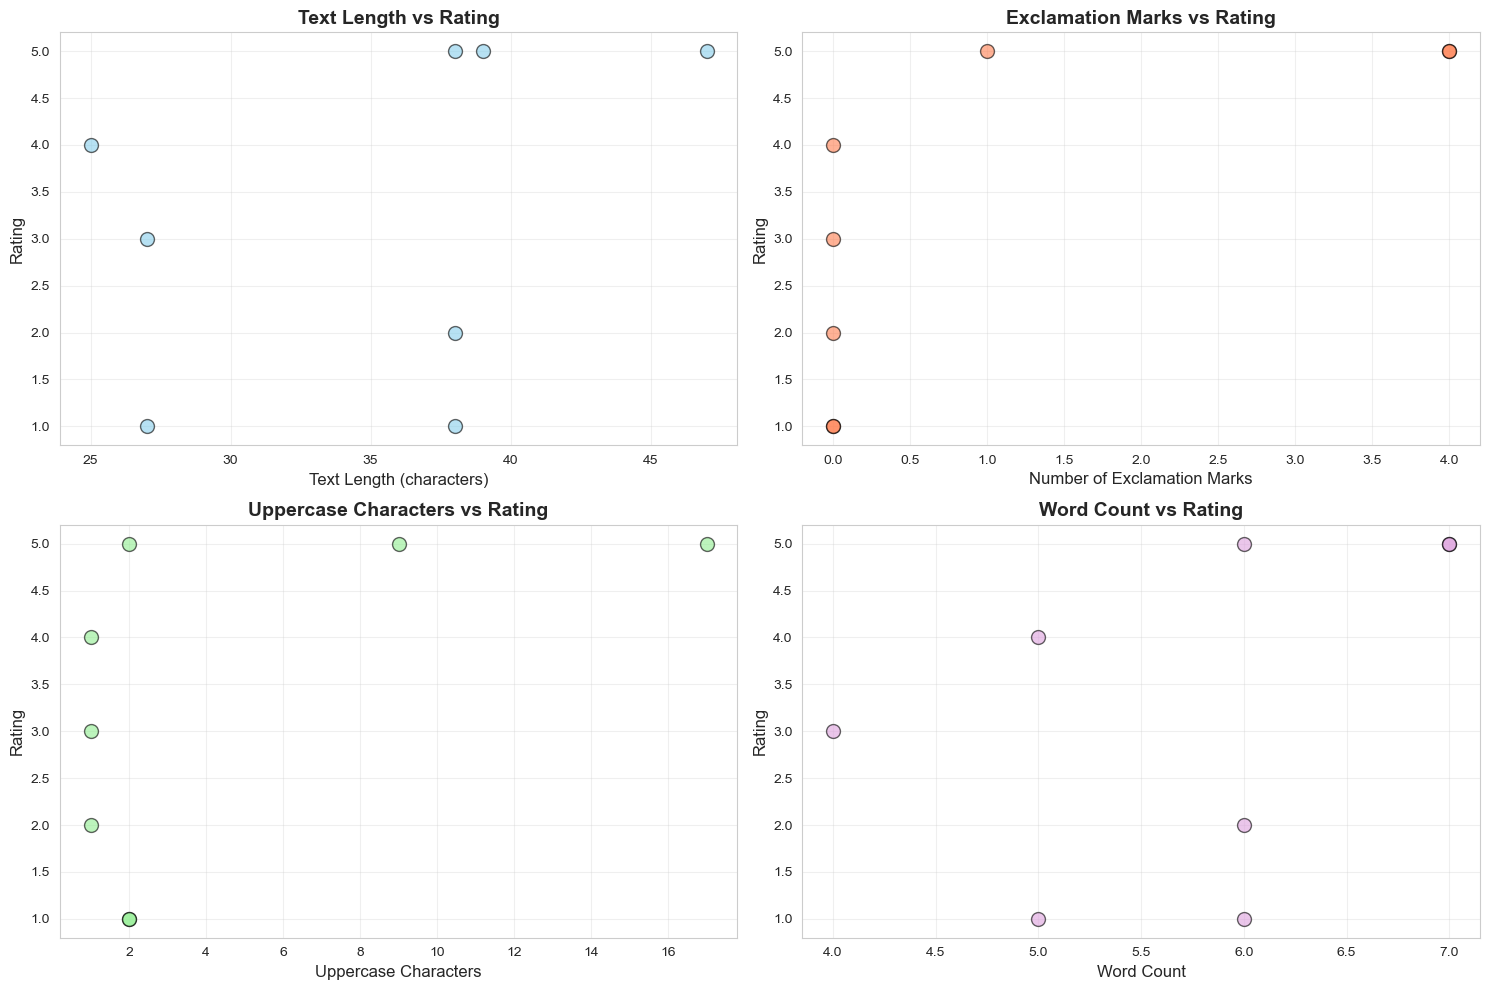


💡 Insight: More exclamation marks often correlate with extreme ratings (very positive or very negative)!


In [4]:
# Visualize relationship between features and ratings
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Text length vs rating
axes[0, 0].scatter(df_reviews['length'], df_reviews['rating'], s=100, alpha=0.6, c='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Text Length (characters)', fontsize=12)
axes[0, 0].set_ylabel('Rating', fontsize=12)
axes[0, 0].set_title('Text Length vs Rating', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Exclamation marks vs rating
axes[0, 1].scatter(df_reviews['exclamation_count'], df_reviews['rating'], s=100, alpha=0.6, c='coral', edgecolor='black')
axes[0, 1].set_xlabel('Number of Exclamation Marks', fontsize=12)
axes[0, 1].set_ylabel('Rating', fontsize=12)
axes[0, 1].set_title('Exclamation Marks vs Rating', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Uppercase count vs rating
axes[1, 0].scatter(df_reviews['uppercase_count'], df_reviews['rating'], s=100, alpha=0.6, c='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('Uppercase Characters', fontsize=12)
axes[1, 0].set_ylabel('Rating', fontsize=12)
axes[1, 0].set_title('Uppercase Characters vs Rating', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Word count vs rating
axes[1, 1].scatter(df_reviews['word_count'], df_reviews['rating'], s=100, alpha=0.6, c='plum', edgecolor='black')
axes[1, 1].set_xlabel('Word Count', fontsize=12)
axes[1, 1].set_ylabel('Rating', fontsize=12)
axes[1, 1].set_title('Word Count vs Rating', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Insight: More exclamation marks often correlate with extreme ratings (very positive or very negative)!")

=== BAG OF WORDS (BoW) ===
Converts text into a matrix of word frequencies

Top 10 words found:
['amazing' 'poor' 'price' 'product' 'purchase' 'quality' 'recommend'
 'service' 'special' 'terrible']

Bag of Words Matrix:
   amazing  poor  price  product  purchase  quality  recommend  service  \
0        1     0      0        1         0        0          1        0   
1        0     0      0        0         0        1          0        0   
2        0     0      0        0         0        0          0        0   
3        0     0      0        0         1        0          0        0   
4        0     0      0        0         0        0          0        0   

   special  terrible  
0        0         0  
1        0         1  
2        1         0  
3        0         0  
4        0         0  


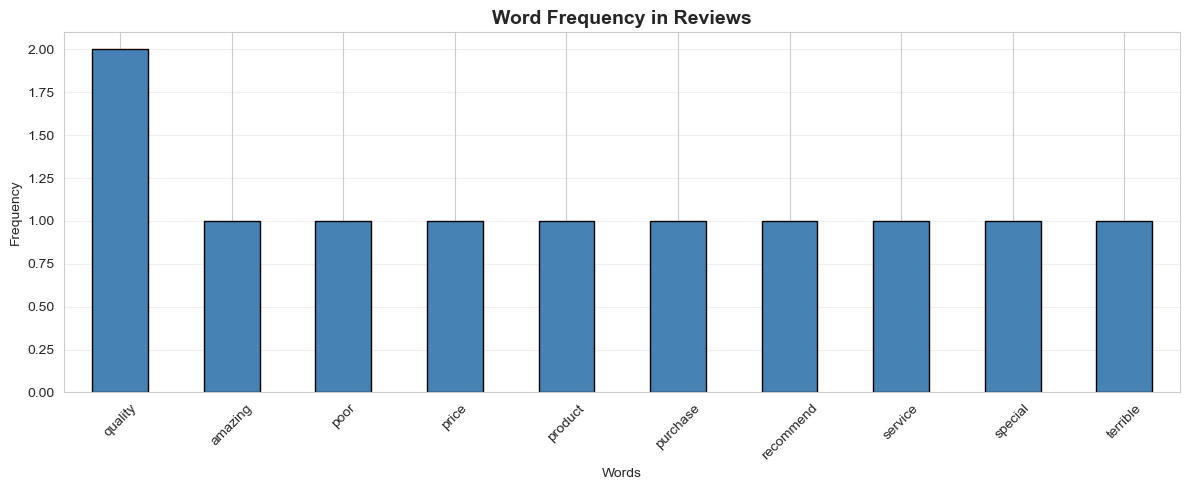

In [5]:
# Advanced: Bag of Words (BoW)
print("=== BAG OF WORDS (BoW) ===")
print("Converts text into a matrix of word frequencies\n")

vectorizer = CountVectorizer(max_features=10, stop_words='english')
bow_matrix = vectorizer.fit_transform(df_reviews['review'])
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())

print("Top 10 words found:")
print(vectorizer.get_feature_names_out())
print("\nBag of Words Matrix:")
print(bow_df.head())

# Show word frequencies
word_freq = bow_df.sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
word_freq.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Word Frequency in Reviews', fontsize=14, fontweight='bold')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 📅 Part 2: Feature Extraction from Dates

A single date column can yield a treasure trove of useful features!

In [6]:
# Create sample sales data with dates
dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='W')
np.random.seed(42)

# Generate sales with patterns
baseline_sales = 1000
sales = []
for date in dates:
    # Base sales
    sale = baseline_sales
    
    # Weekend boost
    if date.dayofweek in [5, 6]:
        sale *= 1.5
    
    # Holiday season boost (Nov-Dec)
    if date.month in [11, 12]:
        sale *= 2.0
    
    # Add some randomness
    sale *= np.random.uniform(0.8, 1.2)
    
    sales.append(int(sale))

df_sales = pd.DataFrame({
    'date': dates,
    'sales': sales
})

print("📈 Sales Dataset with Dates")
print(df_sales.head(10))

📈 Sales Dataset with Dates
        date  sales
0 2023-01-01   1424
1 2023-01-08   1770
2 2023-01-15   1639
3 2023-01-22   1559
4 2023-01-29   1293
5 2023-02-05   1293
6 2023-02-12   1234
7 2023-02-19   1719
8 2023-02-26   1560
9 2023-03-05   1624


In [7]:
# Extract temporal features
def extract_date_features(df, date_column):
    """Extract comprehensive date features"""
    df = df.copy()
    
    # Basic temporal features
    df['year'] = df[date_column].dt.year
    df['month'] = df[date_column].dt.month
    df['day'] = df[date_column].dt.day
    df['day_of_week'] = df[date_column].dt.dayofweek  # Monday=0, Sunday=6
    df['day_of_year'] = df[date_column].dt.dayofyear
    df['week_of_year'] = df[date_column].dt.isocalendar().week
    df['quarter'] = df[date_column].dt.quarter
    
    # Boolean features
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['is_month_start'] = df[date_column].dt.is_month_start.astype(int)
    df['is_month_end'] = df[date_column].dt.is_month_end.astype(int)
    df['is_quarter_start'] = df[date_column].dt.is_quarter_start.astype(int)
    df['is_quarter_end'] = df[date_column].dt.is_quarter_end.astype(int)
    df['is_year_start'] = df[date_column].dt.is_year_start.astype(int)
    df['is_year_end'] = df[date_column].dt.is_year_end.astype(int)
    
    # Seasonal features
    df['is_holiday_season'] = df['month'].isin([11, 12]).astype(int)
    df['is_summer'] = df['month'].isin([6, 7, 8]).astype(int)
    
    # Cyclical encoding (for periodic features)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    return df

df_sales_enriched = extract_date_features(df_sales, 'date')

print("✅ Extracted Date Features:")
print("\nSample of features:")
print(df_sales_enriched[['date', 'sales', 'day_of_week', 'is_weekend', 'month', 'is_holiday_season']].head(10))

print("\nAll temporal features created:")
temporal_cols = [col for col in df_sales_enriched.columns if col not in ['date', 'sales']]
print(temporal_cols)

✅ Extracted Date Features:

Sample of features:
        date  sales  day_of_week  is_weekend  month  is_holiday_season
0 2023-01-01   1424            6           1      1                  0
1 2023-01-08   1770            6           1      1                  0
2 2023-01-15   1639            6           1      1                  0
3 2023-01-22   1559            6           1      1                  0
4 2023-01-29   1293            6           1      1                  0
5 2023-02-05   1293            6           1      2                  0
6 2023-02-12   1234            6           1      2                  0
7 2023-02-19   1719            6           1      2                  0
8 2023-02-26   1560            6           1      2                  0
9 2023-03-05   1624            6           1      3                  0

All temporal features created:
['year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quart

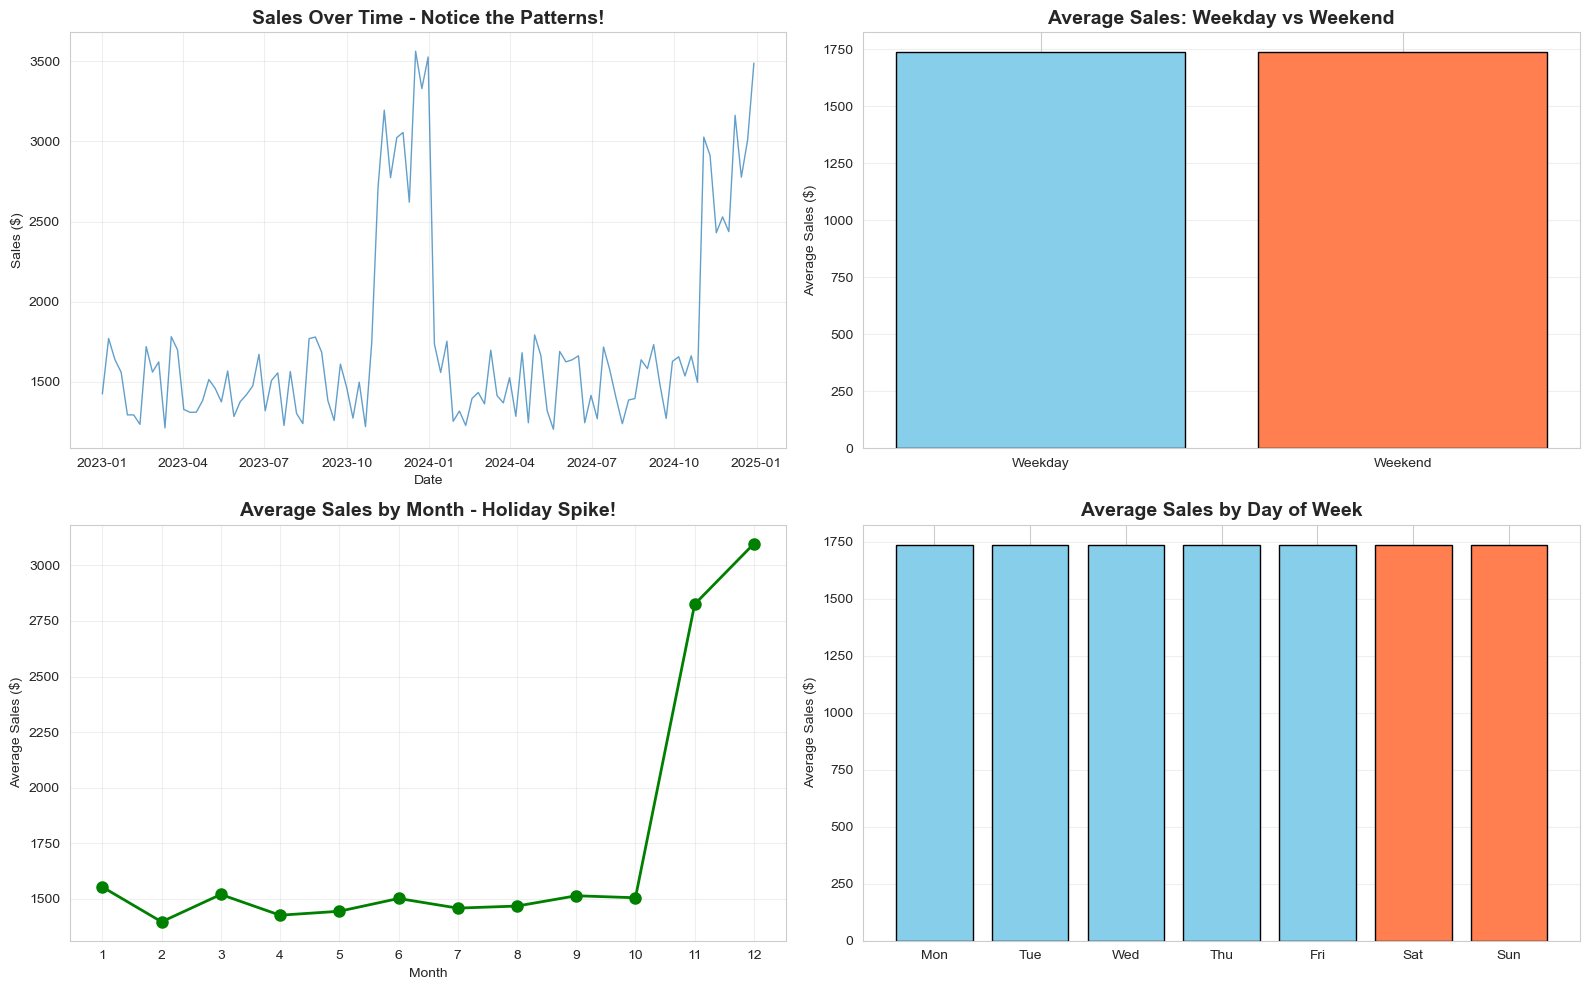


💡 Key Insights:
  - Average sales: $1,737
  - Holiday season (Nov-Dec) shows massive spikes
  - Clear weekly patterns exist


In [9]:
# Visualize temporal patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Sales over time
axes[0, 0].plot(df_sales_enriched['date'], df_sales_enriched['sales'], linewidth=1, alpha=0.7)
axes[0, 0].set_title('Sales Over Time - Notice the Patterns!', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Sales ($)')
axes[0, 0].grid(True, alpha=0.3)

# Weekend vs Weekday
weekend_avg = df_sales_enriched.groupby('is_weekend')['sales'].mean()
axes[0, 1].bar(['Weekday', 'Weekend'], weekend_avg.values, color=['skyblue', 'coral'], edgecolor='black')
axes[0, 1].set_title('Average Sales: Weekday vs Weekend', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Average Sales ($)')
axes[0, 1].grid(axis='y', alpha=0.3)

# Monthly patterns
monthly_avg = df_sales_enriched.groupby('month')['sales'].mean()
axes[1, 0].plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2, markersize=8, color='green')
axes[1, 0].set_title('Average Sales by Month - Holiday Spike!', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Average Sales ($)')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].grid(True, alpha=0.3)

# Day of week patterns
dow_avg = df_sales_enriched.groupby('day_of_week')['sales'].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 1].bar(day_names, dow_avg.values, color=['skyblue']*5 + ['coral']*2, edgecolor='black')
axes[1, 1].set_title('Average Sales by Day of Week', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Average Sales ($)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Key Insights:")
# Check if both weekday and weekend data exist
if len(weekend_avg) == 2:
    weekday_sales = weekend_avg.iloc[0]
    weekend_sales = weekend_avg.iloc[1]
    improvement = ((weekend_sales / weekday_sales - 1) * 100)
    print(f"  - Weekend sales are {improvement:.1f}% higher!")
else:
    print(f"  - Average sales: ${weekend_avg.values[0]:,.0f}")
print(f"  - Holiday season (Nov-Dec) shows massive spikes")
print(f"  - Clear weekly patterns exist")

## 🔄 Part 3: Mathematical Transformations

Transform features to capture non-linear patterns and handle skewness.

In [10]:
# Generate skewed data (like income or house prices)
np.random.seed(42)
n_samples = 1000

# Create right-skewed income data
income_raw = np.exp(np.random.normal(10.5, 1.2, n_samples))  # Log-normal distribution
df_income = pd.DataFrame({'income': income_raw})

print("💰 Income Distribution Analysis")
print(df_income['income'].describe())
print(f"\nSkewness: {df_income['income'].skew():.2f} (>1 means highly right-skewed)")
print(f"Kurtosis: {df_income['income'].kurtosis():.2f} (>3 means heavy tails)")

💰 Income Distribution Analysis
count    1.000000e+03
mean     7.708394e+04
std      1.622807e+05
min      7.428389e+02
25%      1.669549e+04
50%      3.743499e+04
75%      7.902605e+04
max      3.697908e+06
Name: income, dtype: float64

Skewness: 12.78 (>1 means highly right-skewed)
Kurtosis: 255.77 (>3 means heavy tails)


In [11]:
# Apply different transformations
df_income['income_log'] = np.log1p(df_income['income'])  # log(1 + x)
df_income['income_sqrt'] = np.sqrt(df_income['income'])
df_income['income_cbrt'] = np.cbrt(df_income['income'])  # Cube root
df_income['income_boxcox'], _ = stats.boxcox(df_income['income'])  # Auto-optimal transform

print("✅ Transformations applied!")
print("\nSkewness after transformation:")
for col in df_income.columns:
    if col.startswith('income'):
        skew = df_income[col].skew()
        print(f"  {col:20s}: {skew:6.3f}")

✅ Transformations applied!

Skewness after transformation:
  income              : 12.782
  income_log          :  0.117
  income_sqrt         :  2.846
  income_cbrt         :  1.584
  income_boxcox       : -0.000


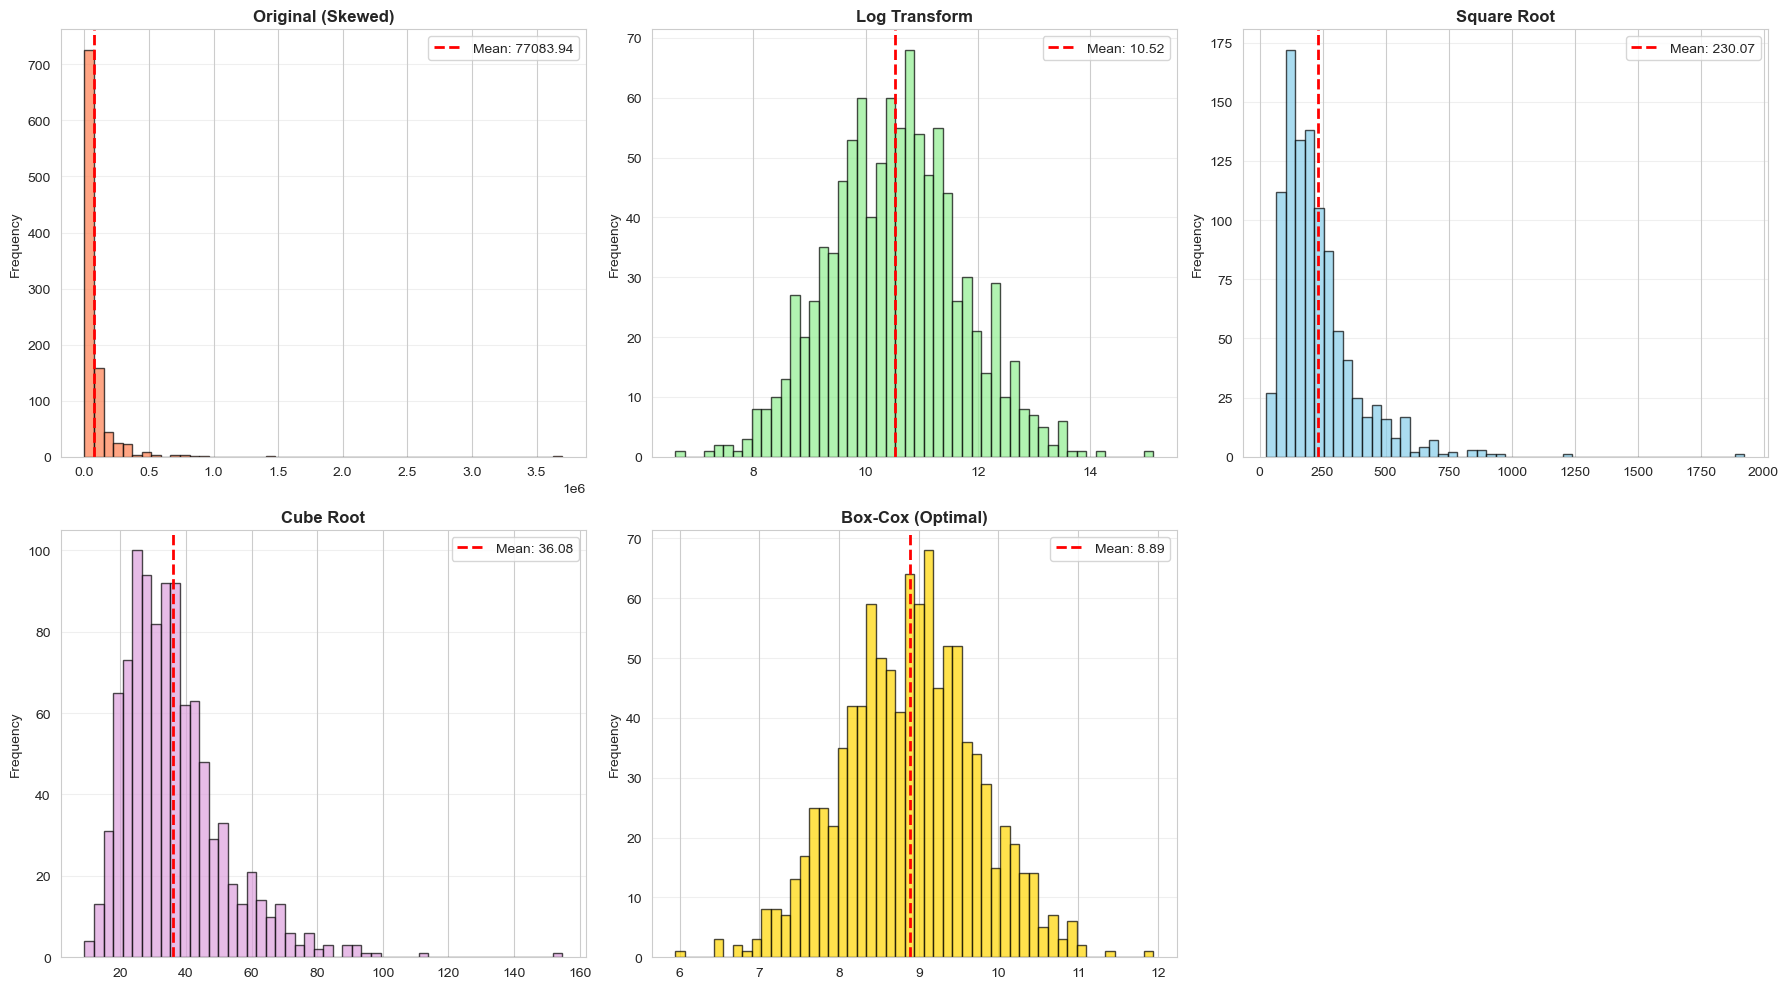


💡 Notice how log and Box-Cox transform make the distribution more 'normal'!
   This helps linear models and algorithms that assume normality.


In [12]:
# Visualize all transformations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

transformations = [
    ('income', 'Original (Skewed)', 'coral'),
    ('income_log', 'Log Transform', 'lightgreen'),
    ('income_sqrt', 'Square Root', 'skyblue'),
    ('income_cbrt', 'Cube Root', 'plum'),
    ('income_boxcox', 'Box-Cox (Optimal)', 'gold')
]

for idx, (col, title, color) in enumerate(transformations):
    row = idx // 3
    col_idx = idx % 3
    
    axes[row, col_idx].hist(df_income[col], bins=50, color=color, edgecolor='black', alpha=0.7)
    axes[row, col_idx].set_title(title, fontsize=12, fontweight='bold')
    axes[row, col_idx].set_ylabel('Frequency')
    axes[row, col_idx].axvline(df_income[col].mean(), color='red', linestyle='--', linewidth=2, 
                                label=f'Mean: {df_income[col].mean():.2f}')
    axes[row, col_idx].legend()
    axes[row, col_idx].grid(axis='y', alpha=0.3)

# Hide the empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("\n💡 Notice how log and Box-Cox transform make the distribution more 'normal'!")
print("   This helps linear models and algorithms that assume normality.")

## 🎨 Part 4: Polynomial Features - Capturing Non-Linear Relationships

Sometimes the relationship isn't a straight line. Polynomial features help capture curves!

In [13]:
# Create synthetic data with non-linear relationship
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 2 * X**2 - 3 * X + 5 + np.random.normal(0, 10, (100, 1))  # Quadratic relationship + noise

df_poly = pd.DataFrame({'X': X.flatten(), 'y': y.flatten()})

print("📊 Non-Linear Dataset Created")
print("True relationship: y = 2x² - 3x + 5 + noise")
print(df_poly.head())

📊 Non-Linear Dataset Created
True relationship: y = 2x² - 3x + 5 + noise
         X          y
0  0.00000   9.967142
1  0.10101   3.334733
2  0.20202  10.952449
3  0.30303  19.504862
4  0.40404   1.772842


In [14]:
# Compare linear vs polynomial regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model 1: Linear regression (will fail to capture curve)
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)
y_pred_linear = model_linear.predict(X_test)
r2_linear = r2_score(y_test, y_pred_linear)

# Model 2: Polynomial regression (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("=== MODEL COMPARISON ===")
print(f"\nLinear Model R² Score: {r2_linear:.4f}")
print(f"Polynomial Model R² Score: {r2_poly:.4f}")
print(f"\nImprovement: {(r2_poly - r2_linear) * 100:.1f}%")
print("\n✅ Polynomial features captured the non-linear pattern!")

=== MODEL COMPARISON ===

Linear Model R² Score: 0.8945
Polynomial Model R² Score: 0.9778

Improvement: 8.3%

✅ Polynomial features captured the non-linear pattern!


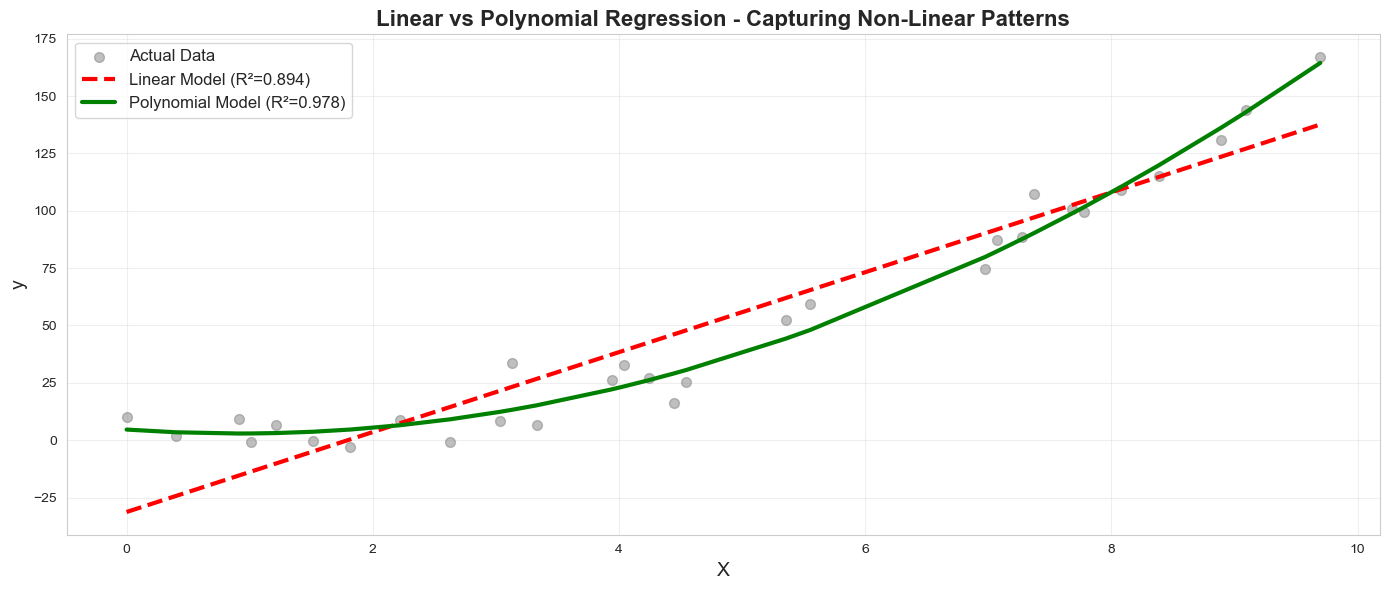


💡 The linear model (red dashed line) can't capture the curve!
   The polynomial model (green line) fits much better.


In [15]:
# Visualize the difference
plt.figure(figsize=(14, 6))

# Sort for smooth lines
sort_idx = X_test.flatten().argsort()
X_test_sorted = X_test[sort_idx]
y_test_sorted = y_test[sort_idx]
y_pred_linear_sorted = y_pred_linear[sort_idx]
y_pred_poly_sorted = y_pred_poly[sort_idx]

# Plot
plt.scatter(X_test, y_test, alpha=0.5, s=50, label='Actual Data', color='gray')
plt.plot(X_test_sorted, y_pred_linear_sorted, linewidth=3, label=f'Linear Model (R²={r2_linear:.3f})', 
         color='red', linestyle='--')
plt.plot(X_test_sorted, y_pred_poly_sorted, linewidth=3, label=f'Polynomial Model (R²={r2_poly:.3f})', 
         color='green')

plt.xlabel('X', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.title('Linear vs Polynomial Regression - Capturing Non-Linear Patterns', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 The linear model (red dashed line) can't capture the curve!")
print("   The polynomial model (green line) fits much better.")

In [16]:
# Show what polynomial features look like
example_X = np.array([[1, 2], [3, 4], [5, 6]])
poly_example = PolynomialFeatures(degree=2, include_bias=False)
X_poly_example = poly_example.fit_transform(example_X)

print("=== POLYNOMIAL FEATURE TRANSFORMATION ===")
print("\nOriginal features: [x₁, x₂]")
print(example_X)

print("\nAfter polynomial transformation (degree=2): [x₁, x₂, x₁², x₁x₂, x₂²]")
print(X_poly_example)

print("\nFeature names:")
print(poly_example.get_feature_names_out())

print("\n📊 From 2 features → 5 features!")
print("   Now the model can learn: y = a·x₁ + b·x₂ + c·x₁² + d·x₁x₂ + e·x₂²")

=== POLYNOMIAL FEATURE TRANSFORMATION ===

Original features: [x₁, x₂]
[[1 2]
 [3 4]
 [5 6]]

After polynomial transformation (degree=2): [x₁, x₂, x₁², x₁x₂, x₂²]
[[ 1.  2.  1.  2.  4.]
 [ 3.  4.  9. 12. 16.]
 [ 5.  6. 25. 30. 36.]]

Feature names:
['x0' 'x1' 'x0^2' 'x0 x1' 'x1^2']

📊 From 2 features → 5 features!
   Now the model can learn: y = a·x₁ + b·x₂ + c·x₁² + d·x₁x₂ + e·x₂²


## 🔗 Part 5: Interaction Features - The Power of Combinations

Sometimes features work better together than individually!

In [17]:
# Create house price dataset
np.random.seed(42)
n_houses = 200

df_houses = pd.DataFrame({
    'sqft': np.random.randint(800, 4000, n_houses),
    'bedrooms': np.random.randint(1, 6, n_houses),
    'bathrooms': np.random.randint(1, 5, n_houses),
    'age_years': np.random.randint(0, 50, n_houses),
    'lot_size': np.random.randint(2000, 10000, n_houses)
})

# Create target (price) with interactions
base_price = 100000
df_houses['price'] = (
    base_price +
    150 * df_houses['sqft'] +
    20000 * df_houses['bedrooms'] +
    15000 * df_houses['bathrooms'] -
    3000 * df_houses['age_years'] +
    10 * df_houses['lot_size'] +
    # INTERACTION TERMS (these are the magic!)
    50 * (df_houses['sqft'] / df_houses['bedrooms']) +  # Spaciousness matters!
    np.random.normal(0, 30000, n_houses)  # Noise
)

print("🏠 House Price Dataset")
print(df_houses.head(10))

🏠 House Price Dataset
   sqft  bedrooms  bathrooms  age_years  lot_size          price
0  3974         3          4         31      9266  907998.805234
1  1660         3          1         36      2510  382897.771609
2  2094         1          4         11      2384  578893.723985
3  1930         5          4         48      2404  475895.903111
4  1895         1          4         12      8966  586522.593567
5  3892         3          1         22      6613  816994.183848
6  2438         2          3         24      6571  582227.403785
7  2969         4          4         34      4000  677747.737984
8  1266         3          2         40      4756  364247.993439
9  2038         1          1         29      3668  498980.084761


In [18]:
# Create interaction features
df_houses_eng = df_houses.copy()

# Ratio features
df_houses_eng['sqft_per_bedroom'] = df_houses_eng['sqft'] / df_houses_eng['bedrooms']
df_houses_eng['sqft_per_bathroom'] = df_houses_eng['sqft'] / df_houses_eng['bathrooms']
df_houses_eng['price_per_sqft'] = df_houses_eng['price'] / df_houses_eng['sqft']
df_houses_eng['lot_to_house_ratio'] = df_houses_eng['lot_size'] / df_houses_eng['sqft']

# Multiplication features
df_houses_eng['total_rooms'] = df_houses_eng['bedrooms'] + df_houses_eng['bathrooms']
df_houses_eng['bedroom_bathroom_product'] = df_houses_eng['bedrooms'] * df_houses_eng['bathrooms']

# Age-related features
df_houses_eng['is_new'] = (df_houses_eng['age_years'] < 5).astype(int)
df_houses_eng['is_old'] = (df_houses_eng['age_years'] > 30).astype(int)

print("✅ Created Interaction Features:")
print("\nNew features:")
new_features = [col for col in df_houses_eng.columns if col not in df_houses.columns]
print(new_features)

print("\nSample data with engineered features:")
print(df_houses_eng[['sqft', 'bedrooms', 'sqft_per_bedroom', 'price']].head())

✅ Created Interaction Features:

New features:
['sqft_per_bedroom', 'sqft_per_bathroom', 'price_per_sqft', 'lot_to_house_ratio', 'total_rooms', 'bedroom_bathroom_product', 'is_new', 'is_old']

Sample data with engineered features:
   sqft  bedrooms  sqft_per_bedroom          price
0  3974         3       1324.666667  907998.805234
1  1660         3        553.333333  382897.771609
2  2094         1       2094.000000  578893.723985
3  1930         5        386.000000  475895.903111
4  1895         1       1895.000000  586522.593567


In [19]:
# Compare models with and without interaction features
original_features = ['sqft', 'bedrooms', 'bathrooms', 'age_years', 'lot_size']
engineered_features = [col for col in df_houses_eng.columns if col not in ['price']]

# Split data
X_orig = df_houses[original_features]
X_eng = df_houses_eng[engineered_features]
y = df_houses['price']

X_orig_train, X_orig_test, y_train, y_test = train_test_split(X_orig, y, test_size=0.3, random_state=42)
X_eng_train, X_eng_test, _, _ = train_test_split(X_eng, y, test_size=0.3, random_state=42)

# Model 1: Original features only
model_orig = LinearRegression()
model_orig.fit(X_orig_train, y_train)
y_pred_orig = model_orig.predict(X_orig_test)
r2_orig = r2_score(y_test, y_pred_orig)
rmse_orig = np.sqrt(mean_squared_error(y_test, y_pred_orig))

# Model 2: With engineered features
model_eng = LinearRegression()
model_eng.fit(X_eng_train, y_train)
y_pred_eng = model_eng.predict(X_eng_test)
r2_eng = r2_score(y_test, y_pred_eng)
rmse_eng = np.sqrt(mean_squared_error(y_test, y_pred_eng))

print("=== MODEL COMPARISON: Impact of Feature Engineering ===")
print(f"\n{'Model':<30} {'R² Score':<15} {'RMSE':<15}")
print("-" * 60)
print(f"{'Original Features (5)':<30} {r2_orig:>10.4f}     ${rmse_orig:>10,.0f}")
print(f"{'With Engineered Features (13)':<30} {r2_eng:>10.4f}     ${rmse_eng:>10,.0f}")
print("-" * 60)
print(f"\n{'Improvement:':<30} {(r2_eng - r2_orig) * 100:>9.1f}%     ${(rmse_orig - rmse_eng):>10,.0f}")

print("\n✨ Feature engineering improved predictions significantly!")
print(f"   Error reduced by ${rmse_orig - rmse_eng:,.0f} on average")

=== MODEL COMPARISON: Impact of Feature Engineering ===

Model                          R² Score        RMSE           
------------------------------------------------------------
Original Features (5)              0.9538     $    38,290
With Engineered Features (13)      0.9866     $    20,639
------------------------------------------------------------

Improvement:                         3.3%     $    17,651

✨ Feature engineering improved predictions significantly!
   Error reduced by $17,651 on average


In [ ]:
# Visualize predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original features
axes[0].scatter(y_test, y_pred_orig, alpha=0.6, s=50, edgecolor='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0].set_title(f'Original Features\nR² = {r2_orig:.4f}', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Engineered features
axes[1].scatter(y_test, y_pred_eng, alpha=0.6, s=50, edgecolor='black', color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price ($)', fontsize=12)
axes[1].set_ylabel('Predicted Price ($)', fontsize=12)
axes[1].set_title(f'With Engineered Features\nR² = {r2_eng:.4f}', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Points closer to the red line = better predictions")
print("   Notice how the right plot (green) is tighter around the red line!")

## 🎓 Summary & Best Practices

### Key Takeaways:

1. **Text Features:**
   - Length, word count, punctuation
   - Bag of Words for word frequencies
   - TF-IDF for importance weighting
   - Sentiment analysis

2. **Date Features:**
   - Extract: year, month, day, day of week
   - Create: is_weekend, is_holiday, quarter
   - Cyclical encoding for periodic features

3. **Transformations:**
   - Log transform for right-skewed data
   - Square root for moderate skewness
   - Box-Cox for automatic optimization

4. **Polynomial Features:**
   - Capture non-linear relationships
   - Creates x², x³, and interaction terms
   - Be careful with high degrees (overfitting!)

5. **Interaction Features:**
   - Ratios: feature1 / feature2
   - Products: feature1 × feature2
   - Differences: feature1 - feature2
   - Domain knowledge is KEY!

### The Feature Engineering Process:
```
1. Understand the problem and domain
2. Explore the data (EDA)
3. Brainstorm feature ideas
4. Create features
5. Test with model
6. Keep what works, remove what doesn't
7. Iterate!
```

### Pro Tips:
- **Talk to experts**: Domain knowledge beats algorithms
- **Start simple**: Basic features first, then get creative
- **Test everything**: A feature idea might sound good but perform poorly
- **Document your work**: You'll forget why you created a feature
- **Don't over-engineer**: More features ≠ better model

---

**Remember:** Feature engineering is often more impactful than choosing the "best" algorithm!

✅ **Notebook Complete! Next: Feature Selection**